In [5]:
"""Tool to plot infer some analysis on TPO"""
from dataclasses import dataclass, field
from os import listdir
import matplotlib.pyplot as plt
from pandas import DataFrame, read_csv, concat
from sklearn.linear_model import LinearRegression
# 
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve

In [6]:
# Global variables
SHOW_PLOTS = False
TEST_OUT = False


@dataclass
class Measurment:
    """Class to represent a measurment"""
    filename: str
    data: DataFrame = field(init=False)
    def __post_init__(self):
        self.data = read_csv(self.filename, sep=';', header=0, skiprows=10)
        # drop first column
        self.data = self.data.drop(self.data.columns[1], axis=1)
        #substitute comma with dot
        self.data = self.data.apply(lambda x: x.str.replace(',','.'))
        self.data = self.data.astype(float)
        self.data.columns = [ 'Time', self.filename]
        self.data['Time'] = self.data['Time']#.apply(lambda x: round(x, 1))
        #print(self.data)
        #plt.plot(self.data[self.filename])

        


    def clean(self, **kwargs):
        """Remove all rows with NaN"""
        self.data = self.data.astype(float)
        #self.data = self.data[self.data["Displacement"] > 0]
        #self.data = self.data[self.data["Displacement"] < 85]    
        self.data = self.data.dropna()
        self.data = self.data.groupby(by='Time').mean()
        self.data = shift(self.data,  **kwargs)
        self.data = smooth(self.data, **kwargs)

    def plot(self, **kwargs):
        """Plot the data"""
        #plt.plot(self.data, label=self.filename, **kwargs)
        # extract the force column
        force = np.asarray(self.data[self.filename])

def shift(df, **kwargs):
    """Shift the data to the right"""
    N = df.where(df > 200).first_valid_index()
    index = np.array(df.index)
    index = index + 10 - N
    df.index = index

    return df

def smooth(df, **kwargs):
    ## take the min in index and max in index
    min_index = df.index.min()
    max_index = df.index.max()
    ## create a new index
    new_index = np.arange(round(min_index, 1), round(max_index, 1), 0.1)
    ## create a new dataframe
    new_df = DataFrame(index=new_index)
    ## interpolate the data
    new_df = new_df.interpolate(method='linear', axis=0)
    ## merge the dataframes
    new_df = new_df.merge(df, left_index=True, right_index=True, how='outer')
    # interpolate the data
    new_df = new_df.interpolate(method='linear', axis=0)
    return new_df


    


   




def PlotterSingle(namedir, N, **kwargs):

    measurments = []
    exp = DataFrame()
    plt.figure(figsize=(10, 5))
    for filename in listdir(namedir):
        measurments.append(Measurment(namedir+"/"+filename))
        measurments[-1].clean(**kwargs)
        #measurments[-1].plot()
    
    # check the min-max index in the dataframes
    t_min = max([i.data.index.min() for i in measurments])
    t_max = min([i.data.index.max() for i in measurments])
    #print(round(t_min, 1), print(t_max, 1))
    # add to exp dataframe the index that goes from tmin to tmax with increments of 0.1
    exp = DataFrame(index=np.arange(round(t_min, 1), round(t_max,1), 0.1))
    for m in measurments:
        exp= concat([exp, m.data], axis=1)
        
    ## if only nans in a row, drop it
    exp = smooth(exp)
    #sprint(exp)
    ## fill with mean nans
    #exp = exp.fillna(exp.mean(axis=1))
#
    #
    #exp.plot(legend=False,linewidth=0.4, figsize=(7, 4), alpha=1)
    #
    mean = exp.mean(axis=1)
    # calculate the integral of the mean
    integral = np.trapz(mean, mean.index)
    print("integral", integral)
    
    ##for i in mean : print(i)
    mean.plot(color="black", legend=False, linewidth=1.5,
              figsize=(7, 4), label="mean")
    display(mean)
    plt.grid()
    std = exp.std(axis=1)
    plt.fill_between(mean.index, mean-std, mean+std, color="C0", alpha=0.5, label = "std")
    plt.xlabel("time [s]")
    plt.ylabel("Force [N]")
    plt.xlim(0, 40)
    plt.ylim(-150, 550)
    plt.title("TPA vegan Lyoner sausage - pork lard")
    plt.tight_layout()
#
    plt.legend()
    if kwargs.get("save_plots", True):
        plt.savefig(namedir+".png", dpi=2000)

    # save the data as a csv file
    exp.to_csv(str(N)+"test.csv", sep=';')

def PlotterMultiple(namedir, displacement,  **kwargs):
    # use single plotter to plot multiple plots
    plt.figure(figsize=(7, 4))
    for N in [2, 4, 6, 8]:
        namedir = str(N)+"perc/csv"
        PlotterSingle(namedir, N, **kwargs)

    

In [7]:
p = 0.9
lam = 10**12
niter = 10
kwargs = {"p": p, "lam": lam, "niter": niter}

SHOW_PLOTS = False

integral 849.6768362259722


-1.740     0.021330
-1.730     0.040540
-1.720     0.028507
-1.710     0.042752
-1.710     0.047327
             ...   
 47.798   -0.007137
 47.808   -0.007866
 47.818   -0.007810
 47.828   -0.007382
 47.830   -0.007437
Length: 21967, dtype: float64

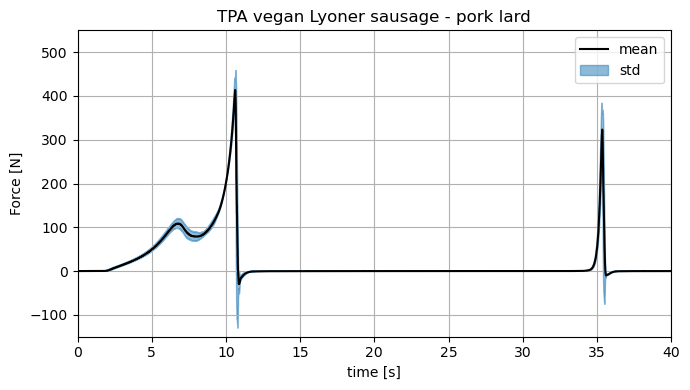

In [8]:
N=2
namedir = "lard/csv"
PlotterSingle(namedir, N, **kwargs)

